# Training Statistics — DF1–DF4 Comparison

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

REPO_ROOT = Path(os.getcwd())
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

In [10]:
models = {}
for name in ['cvae1', 'cvae2', 'cvae3']:
    hist_path = Path(f'checkpoints/{name}/history.json')
    if hist_path.exists():
        with open(hist_path, 'r') as f:
            models[name] = json.load(f)
        print(f'{name}: {len(models[name]["train_loss"])} epochs trained, '
              f'hidden_dim={models[name].get("hidden_dim", "?")}, '
              f'params={models[name].get("n_params", "?"):,}, '
              f'best_val={models[name].get("best_val_loss", "?"):.4f}')
    else:
        print(f'{name}: not found')

cvae1: 1500 epochs trained, hidden_dim=128, params=47,908, best_val=0.0012
cvae2: 1500 epochs trained, hidden_dim=256, params=167,268, best_val=0.0007
cvae3: 1500 epochs trained, hidden_dim=512, params=596,324, best_val=0.0005


## Training Loss Curves

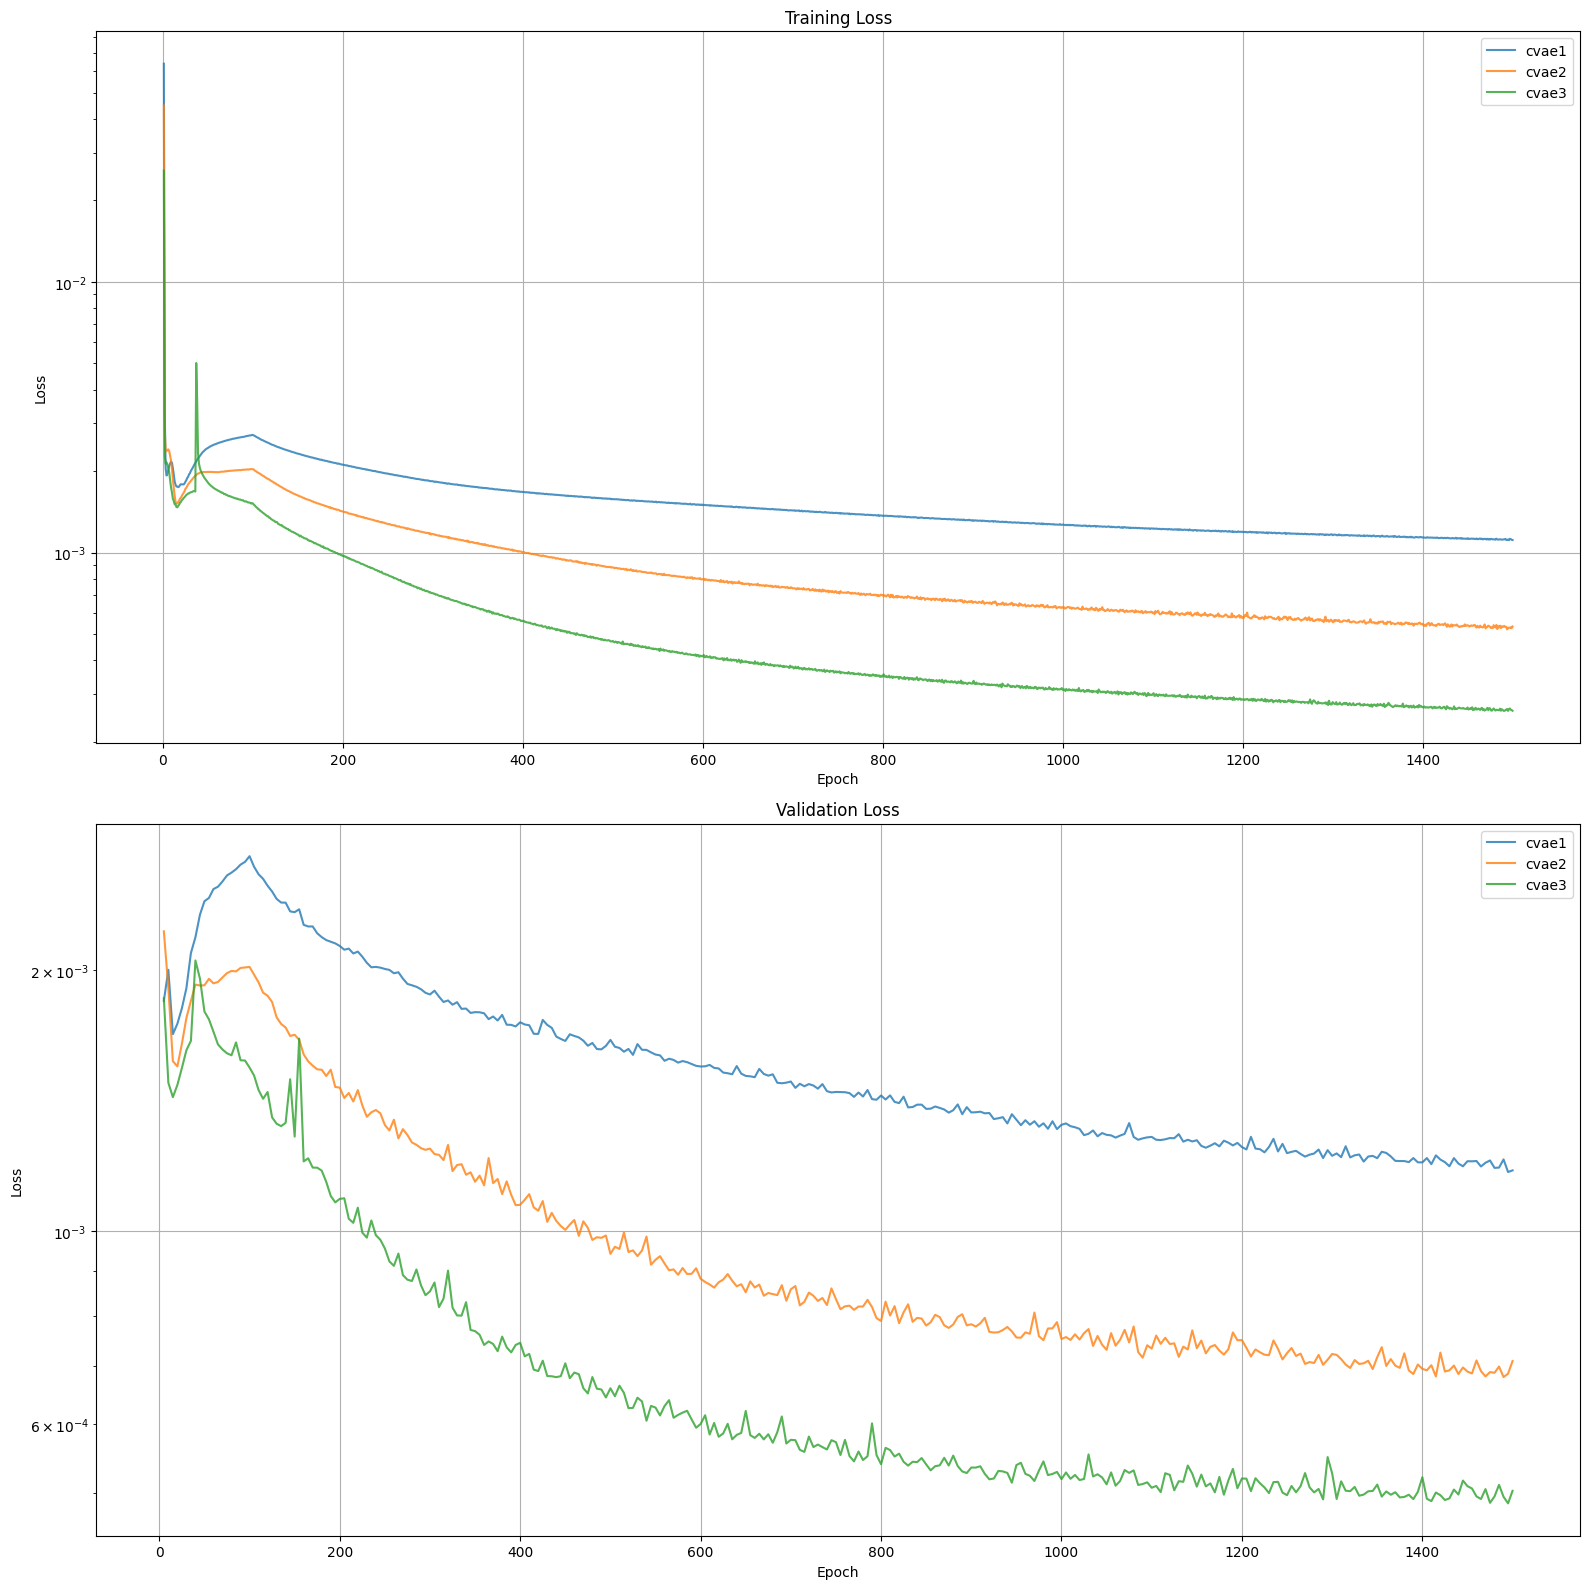

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

for name, hist in models.items():
    epochs = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(epochs, hist['train_loss'], label=name, alpha=0.8)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].set_yscale('log')

for name, hist in models.items():
    axes[1].plot(hist['val_epochs'], hist['val_loss'], label=name, alpha=0.8)

axes[1].set_yscale('log')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Validation Loss')
axes[1].legend()

plt.tight_layout()

## Zoomed — Last 50% of Training
See the fine convergence behavior after initial drop.

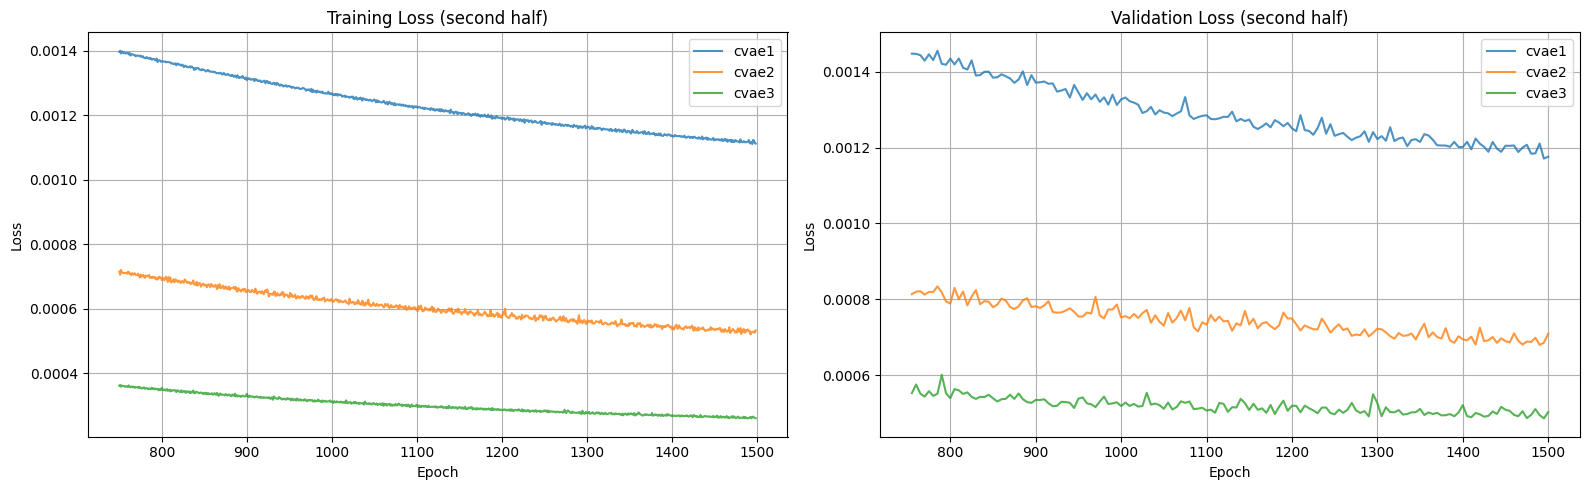

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for name, hist in models.items():
    train = hist['train_loss']
    start = len(train) // 2
    axes[0].plot(range(start, len(train)), train[start:], label=name, alpha=0.8)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss (second half)')
axes[0].legend()

for name, hist in models.items():
    ve = hist['val_epochs']
    vl = hist['val_loss']
    start = len(vl) // 2
    axes[1].plot(ve[start:], vl[start:], label=name, alpha=0.8)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Validation Loss (second half)')
axes[1].legend()

plt.tight_layout()

## Summary Table — Replicating TacDiffusion Table II

In [5]:
print(f'{"Model":<8} {"Neurons (N)":>12} {"Params":>10} {"Final Train":>13} {"Best Val":>10}')
print('-' * 58)
for name, hist in models.items():
    hdim = hist.get('hidden_dim', '?')
    params = hist.get('n_params', '?')
    final_train = hist.get('final_train_loss', hist['train_loss'][-1])
    best_val = hist.get('best_val_loss', min(hist['val_loss']))
    print(f'{name.upper():<8} {hdim:>12} {params:>10,} {final_train:>13.4f} {best_val:>10.4f}')

Model     Neurons (N)     Params   Final Train   Best Val
----------------------------------------------------------
CVAE1             128     47,908        0.0011     0.0012
CVAE2             256    167,268        0.0013     0.0013
CVAE5             192    100,964        0.0007     0.0008


## Train vs Val Gap — Overfitting Check

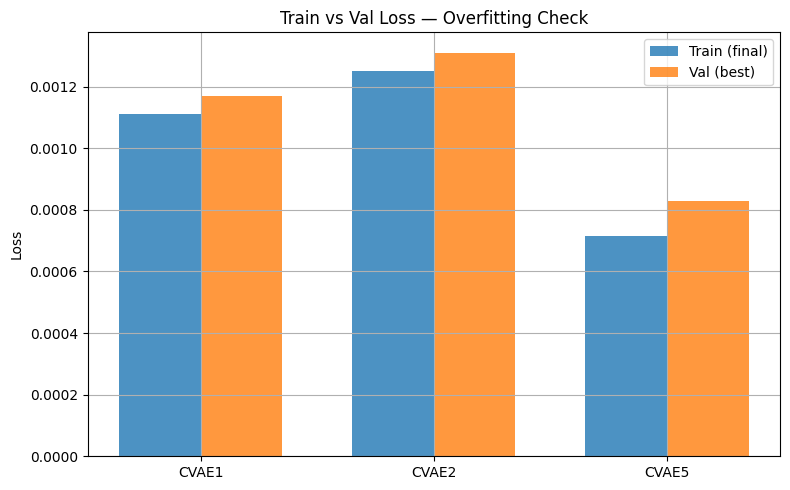

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

names = []
train_vals = []
val_vals = []

for name, hist in models.items():
    names.append(name.upper())
    train_vals.append(hist.get('final_train_loss', hist['train_loss'][-1]))
    val_vals.append(hist.get('best_val_loss', min(hist['val_loss'])))

x = np.arange(len(names))
w = 0.35
ax.bar(x - w/2, train_vals, w, label='Train (final)', alpha=0.8)
ax.bar(x + w/2, val_vals, w, label='Val (best)', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Loss')
ax.set_title('Train vs Val Loss — Overfitting Check')
ax.legend()

for i in range(len(names)):
    gap = val_vals[i] - train_vals[i]
    ax.annotate(f'gap: {gap:.4f}', (x[i], max(train_vals[i], val_vals[i]) + 0.001),
                ha='center', fontsize=9, color='gray')

plt.tight_layout()